In [ ]:
import numpy as np
import pandas as pd


In [8]:
df=pd.read_csv('spam.csv.zip')
df.sample(5)



,Unnamed: 0,label,text,label_num
3598,408,ham,Subject: 1 / 2000 lower colorado river vols\r\...,0
194,1279,ham,Subject: re : centana mobil april 00\r\npanene...,0
3680,3913,spam,Subject: buy a home today bad credit no proble...,1
4244,778,ham,Subject: performance review - mid - year\r\nfo...,0
427,2754,ham,Subject: bayer - march 2001 volumes\r\njust wa...,0


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


# **1.  Data Cleaning**

In [10]:
df.rename(columns={'label':'target'}, inplace=True)
df.sample(5)

,Unnamed: 0,target,text,label_num
4315,2100,ham,"Subject: cornhusker\r\nhi darrin ,\r\nthis is ...",0
4977,2163,ham,"Subject: goings on\r\nhi again ,\r\n?\r\ni can...",0
4382,2088,ham,Subject: gas management agreement\r\nattached ...,0
1985,157,ham,Subject: review texas budget meeting\r\nplease...,0
5100,4715,spam,Subject: order verification\r\n% rnd _ alt % r...,1


In [11]:
df.sample(5)

,Unnamed: 0,target,text,label_num
123,2225,ham,Subject: hpl meter # 980417 hpl / kmid - seven...,0
3861,822,ham,Subject: june 2000 co - owners volumes\r\n- - ...,0
2328,3627,ham,Subject: econnect vpn\r\nyou have been approve...,0
2163,1165,ham,Subject: re : brandywine meter # : 1428\r\nple...,0
1454,3534,ham,Subject: tenaska iv\r\ndarren :\r\nplease chan...,0


In [12]:
df.sample(5)


,Unnamed: 0,target,text,label_num
1939,2344,ham,Subject: discussion january 10\r\nwe ' re baaa...,0
1946,4597,spam,Subject: whats up . b u y all of your meds her...,1
405,505,ham,Subject: calpine daily gas nomination\r\n- cal...,0
4502,4112,spam,"Subject: welcome to toronto pharmac euticals ,...",1
3301,3596,ham,Subject: enron announces plans to merge with d...,0


In [13]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['target']=encoder.fit_transform(df['target'])
df.head()

,Unnamed: 0,target,text,label_num
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0


In [14]:
df.isnull().sum()

,0
Unnamed: 0,0
target,0
text,0
label_num,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [17]:
df.sample(5)

,Unnamed: 0,target,text,label_num
159,255,0,Subject: notes from initial enom use case meet...,0
1183,1796,0,Subject: cornhusker\r\nwhere are we on the gas...,0
125,1833,0,"Subject: re : cornhusker\r\njohn ,\r\ni have a...",0
2855,993,0,Subject: sap changes\r\nwith sap now here ther...,0
2559,1127,0,"Subject: hpl nom for july 1 , 2000\r\n( see at...",0


In [18]:
df.shape

(5171, 4)

# **2.  EDA**


In [19]:
df['target'].value_counts()

,count
target,
0,3672
1,1499


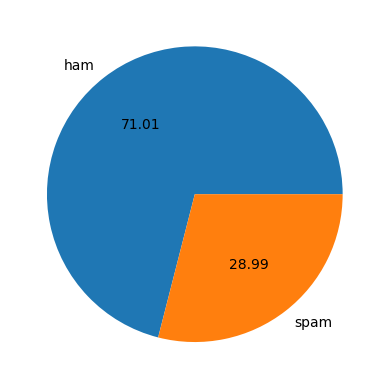

In [20]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [21]:
import nltk

In [22]:
!pip install nltk

In [23]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [25]:
df['num_characters']=df['text'].apply(len)

In [26]:
df.head()

,Unnamed: 0,target,text,label_num,num_characters
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0,327
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1,414
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0,336


In [27]:
nltk.download('punkt_tab')
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [28]:
df.head()

,Unnamed: 0,target,text,label_num,num_characters,num_words
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0,327,68
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97,24
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524,551
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1,414,49
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0,336,71


In [29]:
df['num_sent']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [30]:
df.head()

,Unnamed: 0,target,text,label_num,num_characters,num_words,num_sent
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0,327,68,3
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97,24,3
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524,551,24
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1,414,49,3
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0,336,71,3


In [31]:
df[['num_characters','num_words','num_sent']].describe()

,num_characters,num_words,num_sent
count,5171.000000,5171.000000,5171.000000
mean,1048.391994,229.181009,13.121253
std,1528.513435,336.487397,27.541637
min,11.000000,2.000000,1.000000
25%,244.000000,52.000000,4.000000
50%,540.000000,122.000000,7.000000
75%,1237.000000,283.500000,15.000000
max,32258.000000,8863.000000,1204.000000


for ham

In [32]:
df[df['target']==0][['num_characters','num_words','num_sent']].describe()

,num_characters,num_words,num_sent
count,3672.000000,3672.000000,3672.000000
mean,977.008170,226.239107,11.440904
std,1382.827493,332.179661,24.892442
min,18.000000,3.000000,1.000000
25%,231.750000,51.000000,3.000000
50%,530.000000,124.000000,6.000000
75%,1227.250000,294.000000,13.000000
max,32258.000000,8863.000000,1204.000000


for spam

In [33]:
df[df['target']==1][['num_characters','num_words','num_sent']].describe()

,num_characters,num_words,num_sent
count,1499.000000,1499.000000,1499.000000
mean,1223.256171,236.387592,17.237492
std,1825.986210,346.821249,32.796043
min,11.000000,2.000000,1.000000
25%,283.000000,55.000000,4.000000
50%,576.000000,116.000000,9.000000
75%,1253.500000,244.000000,18.500000
max,22073.000000,3963.000000,693.000000


In [34]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

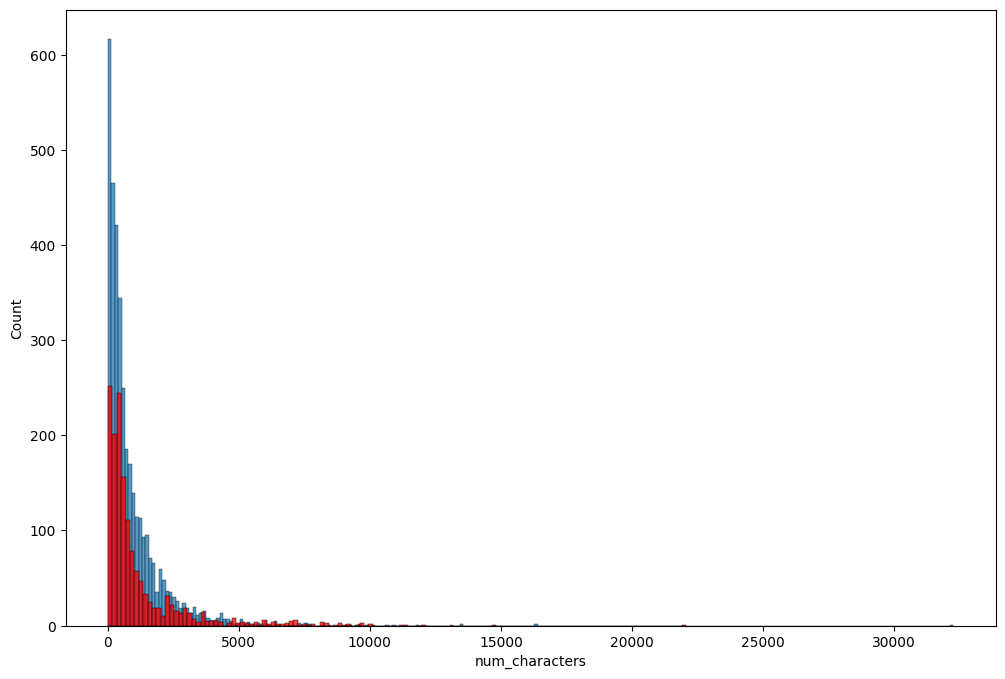

In [35]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

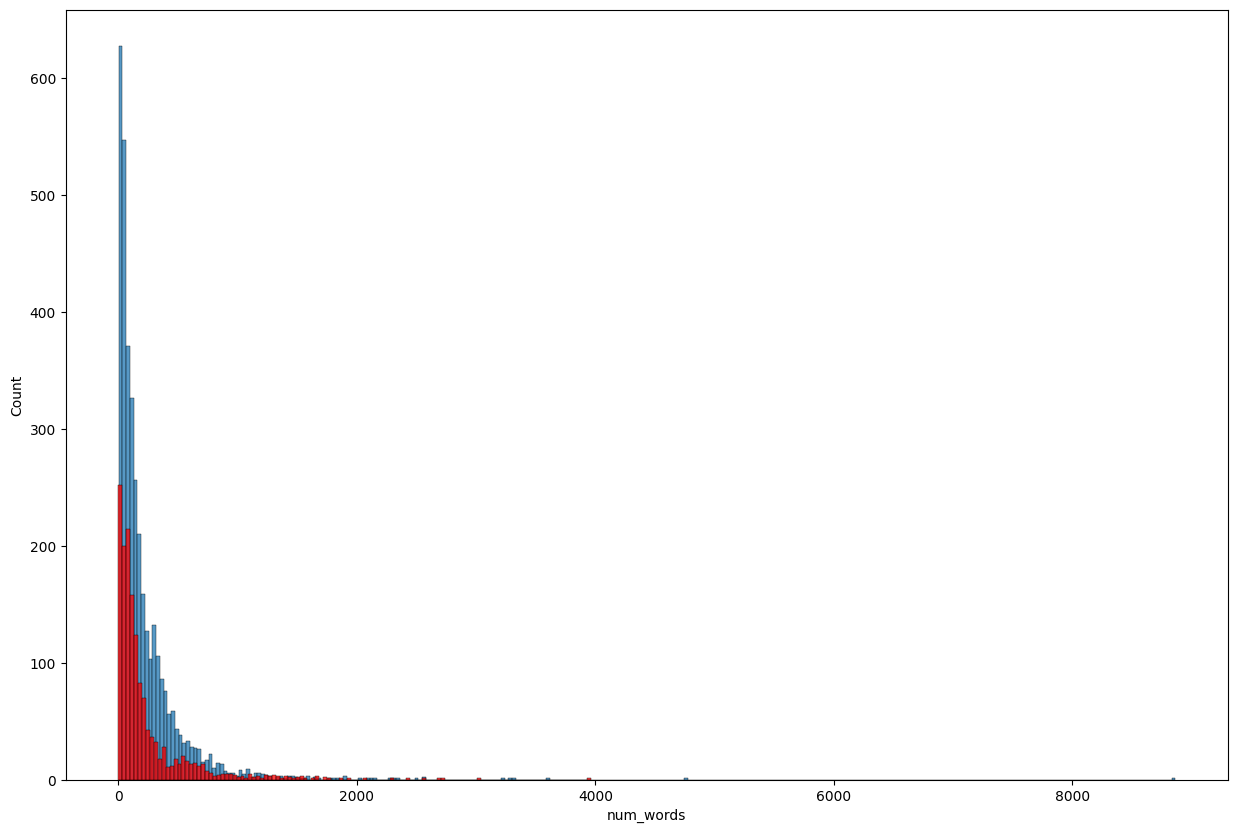

In [36]:
plt.figure(figsize=(15,10))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

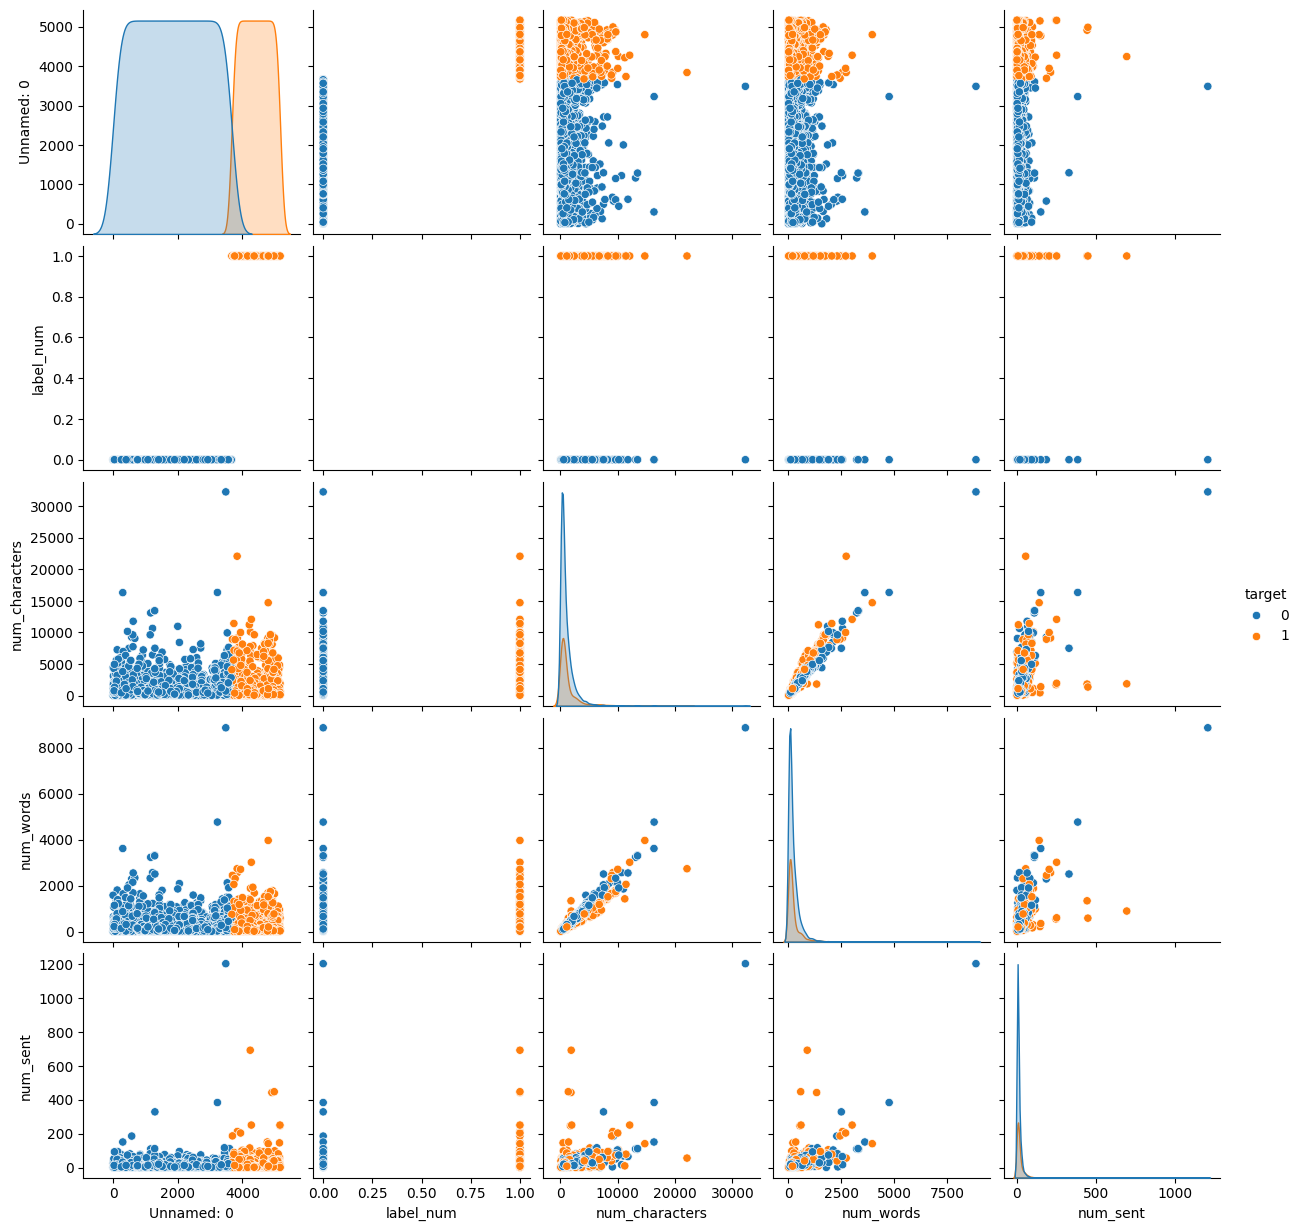

In [37]:
sns.pairplot(df,hue='target')

<Axes: >

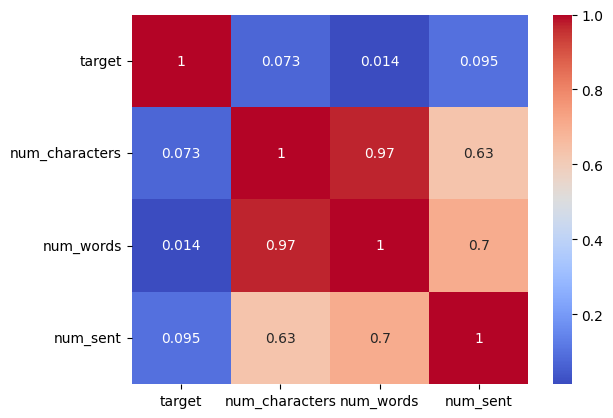

In [38]:
sns.heatmap(df[['target', 'num_characters', 'num_words', 'num_sent']].corr(), annot=True, cmap='coolwarm')

# **3.  Data preprocessing**

In [39]:
def transform_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)

  y=[]
  for i in text:
     if i.isalnum():
         y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if  i!='subject' and i not in stopwords.words('english') and i not in string.punctuation :
      y.append(i)

  text=y[:]
  y.clear()

  for i in text:
      y.append(ps.stem(i))

  return " ".join(y)

In [40]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [41]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [45]:
transform_text('will this project identify spam and ham emails?')

'project identifi spam ham email'

In [43]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('programming')

'program'

In [46]:
df['transformed_text']=df['text'].apply(transform_text)

In [47]:
df.head()

,Unnamed: 0,target,text,label_num,num_characters,num_words,num_sent,transformed_text
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0,327,68,3,enron methanol meter 988291 follow note gave m...
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97,24,3,hpl nom januari 9 2001 see attach file hplnol ...
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524,551,24,neon retreat ho ho ho around wonder time year ...
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1,414,49,3,photoshop window offic cheap main trend abas d...
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0,336,71,3,indian spring deal book teco pvr revenu unders...


In [48]:
from wordcloud import WordCloud
wc=WordCloud( width=500, height=500, min_font_size=10, background_color='white')
spam_wc= wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

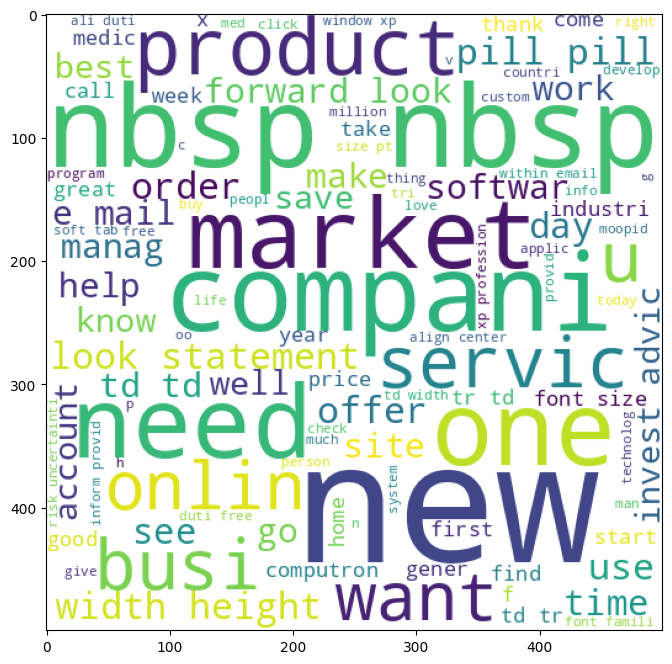

In [49]:
plt.figure(figsize=(15,8))
plt.imshow(spam_wc)

In [50]:
ham_wc= wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

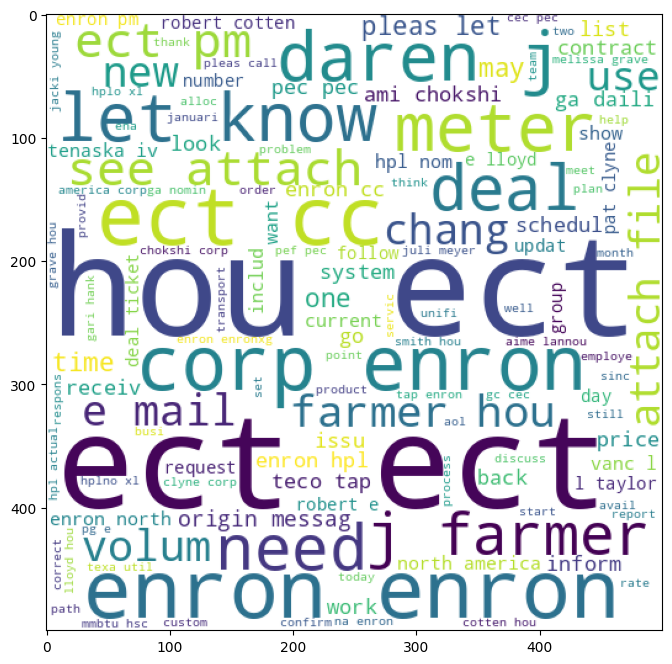

In [51]:
plt.figure(figsize=(15,8))
plt.imshow(spam_wc)

In [52]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [53]:
len(spam_corpus)

195795

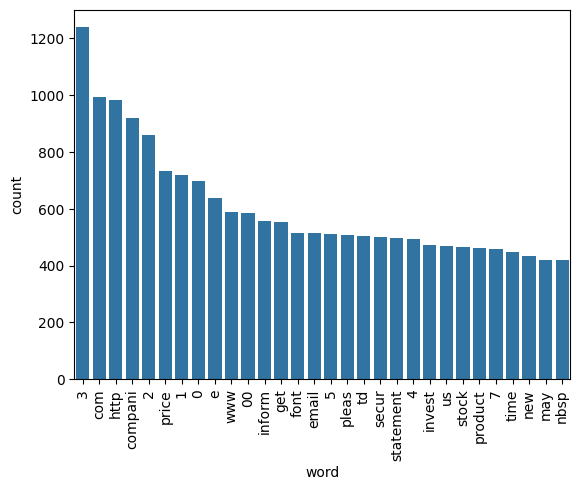

In [54]:
from collections import Counter
spam_word_counts = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(x='word', y='count', data=spam_word_counts)
plt.xticks(rotation='vertical')
plt.show()

# **4.  Model Training**

In [55]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer()


In [56]:
x=cv.fit_transform(df['transformed_text']).toarray()

In [57]:
x.shape

(5171, 42592)

In [58]:
y=df['target'].values
y

array([0, 0, 0, ..., 0, 0, 1])

In [59]:
from sklearn.model_selection import train_test_split


In [60]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [61]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()


In [62]:
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.9642512077294686
[[734  12]
 [ 25 264]]
0.9565217391304348


In [63]:
mnb.fit(x_train,y_train)
y_pred2=gnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9642512077294686
[[734  12]
 [ 25 264]]
0.9565217391304348


In [64]:
bnb.fit(x_train,y_train)
y_pred3=gnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9642512077294686
[[734  12]
 [ 25 264]]
0.9565217391304348


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bgc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bgc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [66]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bgc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [67]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bgc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [68]:
def train_classifier(clf,x_train, y_train, x_test,y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    return accuracy, precision

In [69]:
train_classifier(svc, x_train,y_train, x_test,y_test)


(0.8222222222222222, 0.6732673267326733)

In [70]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, x_train, y_train, x_test, y_test)
    print("For ", name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.8222222222222222
Precision -  0.6732673267326733
For  KN
Accuracy -  0.8338164251207729
Precision -  0.6320541760722348
For  NB
Accuracy -  0.9729468599033816
Precision -  0.9423728813559322
For  DT
Accuracy -  0.8560386473429952
Precision -  0.6707317073170732
For  LR
Accuracy -  0.9729468599033816
Precision -  0.9278688524590164
For  RF
Accuracy -  0.978743961352657
Precision -  0.9525423728813559
For  AdaBoost
Accuracy -  0.9227053140096618
Precision -  0.8255451713395638
For  BgC
Accuracy -  0.9458937198067633
Precision -  0.8949152542372881
For  ETC
Accuracy -  0.9748792270531401
Precision -  0.9368770764119602
For  GBDT
Accuracy -  0.9497584541062802
Precision -  0.8761904761904762
For  xgb
Accuracy -  0.9758454106280193
Precision -  0.9342105263157895


In [71]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores})

In [72]:
performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.822222,0.673267
1,KN,0.833816,0.632054
2,NB,0.972947,0.942373
3,DT,0.856039,0.670732
4,LR,0.972947,0.927869
5,RF,0.978744,0.952542
6,AdaBoost,0.922705,0.825545
7,BgC,0.945894,0.894915
8,ETC,0.974879,0.936877
9,GBDT,0.949758,0.876190


In [73]:
performance_df1= pd.melt(performance_df, id_vars="Algorithm")
performance_df1

,Algorithm,variable,value
0,SVC,Accuracy,0.822222
1,KN,Accuracy,0.833816
2,NB,Accuracy,0.972947
3,DT,Accuracy,0.856039
4,LR,Accuracy,0.972947
5,RF,Accuracy,0.978744
6,AdaBoost,Accuracy,0.922705
7,BgC,Accuracy,0.945894
8,ETC,Accuracy,0.974879
9,GBDT,Accuracy,0.949758


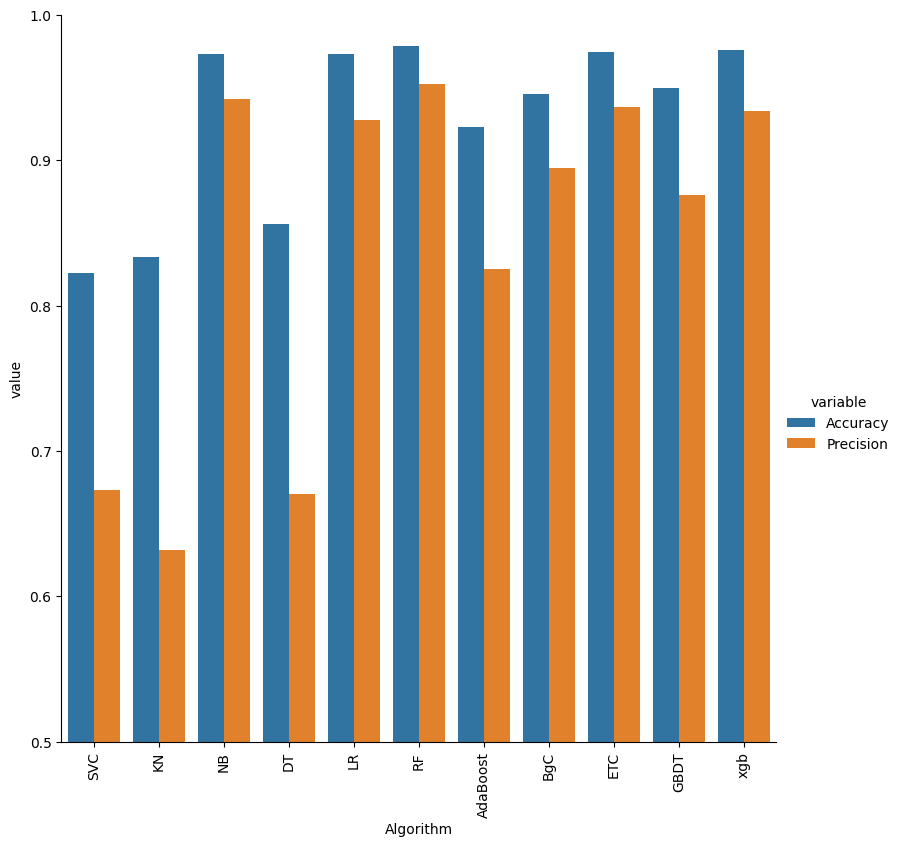

In [74]:
sns.catplot(x="Algorithm", y="value", hue="variable", data=performance_df1, kind="bar", height=8)
plt.ylim(0.5,1)
plt.xticks(rotation='vertical')
plt.show()

In [75]:
import pickle
pickle.dump(cv,open('CountVectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [76]:
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)
PATH='/Users/roopshreesingh/Downloads/Email Spam Detection system'

Mounted at /content/drive


In [82]:
file_name="CountVectorizer.pkl"
# Correcting the path to load from the Colab environment's /content directory
path_to_embedded=os.path.join('/content',file_name)
print(path_to_embedded)
df=pickle.load(open(path_to_embedded,"rb"))

/content/CountVectorizer.pkl


In [83]:
file_name="model.pkl"
path_to_embedded=os.path.join('/content',file_name)
print(path_to_embedded)
df=pickle.load(open(path_to_embedded,"rb"))

/content/model.pkl
